# ChromaDB와 Text2SQL
* Day 16 핵심 개념을 **짧은 코드로 한 번씩** 확인합니다.
* 데이터: `rag_data/` 의 **학부 학칙**·**일반대학원 학칙** PDF, `table_data.csv`


---
* `day15` Conda 환경을 사용합니다.
* Chroma·PDF·웹검색·SQLite 관련 패키지를 설치합니다.

In [1]:
!pip install langchain langchain-openai langchain-community langchain-chroma langchain-text-splitters langgraph pypdf chromadb ddgs pandas

In [2]:
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
OPENAI_API_KEY = __import__('os').getenv('OPENAI_API_KEY')

WORKDIR = Path.cwd()
RAG_DIR = WORKDIR / 'rag_data'
PDF_PATHS = sorted(RAG_DIR.glob('*.pdf'))  # 학부 + 일반대학원
CSV_PATH = RAG_DIR / 'table_data.csv'
CHROMA_DIR = WORKDIR / 'chroma_regulations'  # 학부·대학원 함께 인덱싱

print('WORKDIR :', WORKDIR)
print('PDFs    :', [p.name for p in PDF_PATHS])
print('CSV     :', CSV_PATH.name)


WORKDIR : /Users/seorincho/Desktop/code/2026_AI/SK Autonomous R&D/16일차
PDFs    : ['연세대학교 일반대학원 학칙.pdf', '연세대학교 학부 학칙.pdf']
CSV     : table_data.csv


---
## 1. ChromaDB 구축

| 선택지 | 특징 |
|--------|------|
| FAISS | 가볍고 빠르지만, 운영·영구저장 기능이 약함 |
| ChromaDB | 로컬 persist 가능, LangChain 연동이 편함 |
| Milvus / Pinecone | 대규모·클라우드 |

### PDF 로드
* 학부 / 일반대학원 PDF를 각각 읽고, 파일명 기준으로 `level` 메타데이터를 붙입니다.


In [3]:
from langchain_community.document_loaders import PyPDFLoader
pdf_path=PDF_PATHS[0]
loaded=PyPDFLoader(str(pdf_path)).load()

/var/folders/pz/g1s7yv693t5ddnqs0qzvsqvr0000gn/T/ipykernel_63569/2089313782.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [4]:
loaded[0]

Document(metadata={'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2024 13.0.0.3457', 'creationdate': '2026-06-17T16:37:51+09:00', 'author': 'DR', 'moddate': '2026-06-17T16:37:51+09:00', 'pdfversion': '1.4', 'source': '/Users/seorincho/Desktop/code/2026_AI/SK Autonomous R&D/16일차/rag_data/연세대학교 일반대학원 학칙.pdf', 'total_pages': 35, 'page': 0, 'page_label': '1'}, page_content='Ⅰ. 대학원 학칙  /  7\nⅠ. 대학원 학칙제정: 1974. 05. 18.개정(제122차): 2026. 06. 06.제1장 총칙제1조(목적) 대학원은 기독교 정신을 바탕으로 하여 창의적 이론과 과학적 방법을 탐구하고, 지도적 인격을 도야하여 인류 문화 향상에 기여함을 목적으로 한다.제2장 과정 및 정원제2조(과정) 대학원에는 석사학위를 취득하기 위한 석사학위과정, 박사학위를 취득하기 위한 박사학위과정, 석사학위과정을 거치지 않고 박사학위를 취득하기 위하여 석사학위과정과 박사학위과정이 통합된 과정(석·박사 통합과정, 이하 “통합과정”)을 두며, 학위과정 외에 학위를 수여하지 아니하는 연구과정을 둘 수 있다.제2조의2(협동과정) ① 대학원에 두는 학위과정으로 학과 외에 두 개 이상의 학과가 공동으로 설치·운영하는 협동과정(이하 “학과 간 협동과정”이라 한다)과 연구기관 또는 산업체와의 계약에 의하여 설치·운영하는 학·연·산 협동과정(이하 “학·연·산 협동과정”이라 한다)을 둘 수 있다.② 대학원장은 학과 간 협동과정의 운영실적을 2년마다 평가하여 대학원운영위원회 의결을 거쳐 존속여부를 결정하며, 이에 관한 사항은 따로 정한다.③ <삭제> 제2조의3 <삭제>제2조의4 <삭제>제2조의5(연계과정

In [27]:
from langchain_community.document_loaders import PyPDFLoader


def infer_level(filename: str) -> str:
    """파일명으로 학부 / 대학원을 구분합니다. (학부를 먼저 검사)"""
    if '학부' in filename:
        return '학부'
    if '대학원' in filename:
        return '대학원'
    return '기타'


pages = []
for pdf_path in PDF_PATHS:
    loaded = PyPDFLoader(str(pdf_path)).load()
    level = infer_level(pdf_path.name)
    for doc in loaded:
        doc.metadata['level'] = level
        doc.metadata['doc_type'] = '학칙'
        doc.metadata['source_file'] = pdf_path.name
    print(f'{pdf_path.name} → level={level}, pages={len(loaded)}')
    pages.extend(loaded)

print('총 페이지:', len(pages))
print(pages[0].metadata)
print("---------------------------------")
print(pages[0].page_content[:200])


연세대학교 일반대학원 학칙.pdf → level=대학원, pages=35
연세대학교 학부 학칙.pdf → level=학부, pages=41
총 페이지: 76
{'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2024 13.0.0.3457', 'creationdate': '2026-06-17T16:37:51+09:00', 'author': 'DR', 'moddate': '2026-06-17T16:37:51+09:00', 'pdfversion': '1.4', 'source': '/Users/seorincho/Desktop/code/2026_AI/SK Autonomous R&D/16일차/rag_data/연세대학교 일반대학원 학칙.pdf', 'total_pages': 35, 'page': 0, 'page_label': '1', 'level': '대학원', 'doc_type': '학칙', 'source_file': '연세대학교 일반대학원 학칙.pdf'}
---------------------------------
Ⅰ. 대학원 학칙  /  7
Ⅰ. 대학원 학칙제정: 1974. 05. 18.개정(제122차): 2026. 06. 06.제1장 총칙제1조(목적) 대학원은 기독교 정신을 바탕으로 하여 창의적 이론과 과학적 방법을 탐구하고, 지도적 인격을 도야하여 인류 문화 향상에 기여함을 목적으로 한다.제2장 과정 및 정원제2조(과정) 대학원에는 석사학위를 취득하기 위한 석사


### Chunk + overlap
* chunk가 너무 작으면 문맥이 끊기고, 너무 크면 주제가 섞입니다.
* `chunk_overlap`으로 경계에서 문맥이 끊기는 것을 줄입니다.

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=120)
chunks = splitter.split_documents(pages)
print('chunk 수:', len(chunks))

chunk 수: 195


In [7]:
print(chunks[0].page_content[:400])
print('--- metadata ---')
print(chunks[0].metadata)

Ⅰ. 대학원 학칙  /  7
--- metadata ---
{'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2024 13.0.0.3457', 'creationdate': '2026-06-17T16:37:51+09:00', 'author': 'DR', 'moddate': '2026-06-17T16:37:51+09:00', 'pdfversion': '1.4', 'source': '/Users/seorincho/Desktop/code/2026_AI/SK Autonomous R&D/16일차/rag_data/연세대학교 일반대학원 학칙.pdf', 'total_pages': 35, 'page': 0, 'page_label': '1', 'level': '대학원', 'doc_type': '학칙', 'source_file': '연세대학교 일반대학원 학칙.pdf'}


### Metadata 태깅
* 벡터 유사도만 쓰면 학부·대학원 조항이 섞여 나올 수 있습니다.
* 로드 단계에서 붙인 `level`(`학부` / `대학원`)을 chunk에도 유지하고, 검색 시 필터에 사용합니다.


In [8]:
# chunk로 나눈 뒤에도 level이 유지되는지 확인
from collections import Counter

level_counts = Counter(c.metadata.get('level') for c in chunks)
print('level별 chunk 수:', dict(level_counts))

for level in ['학부', '대학원']:
    sample = next(c for c in chunks if c.metadata.get('level') == level)
    print(f'[{level}]', sample.metadata)


level별 chunk 수: {'대학원': 102, '학부': 93}
[학부] {'producer': 'Skia/PDF m150', 'creator': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36', 'creationdate': '2026-07-11T13:36:30+00:00', 'title': '연세대학교 학칙 ::연세대학교 규정집', 'moddate': '2026-07-11T13:36:30+00:00', 'source': '/Users/seorincho/Desktop/code/2026_AI/SK Autonomous R&D/16일차/rag_data/연세대학교 학부 학칙.pdf', 'total_pages': 41, 'page': 0, 'page_label': '1', 'level': '학부', 'doc_type': '학칙', 'source_file': '연세대학교 학부 학칙.pdf'}
[대학원] {'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2024 13.0.0.3457', 'creationdate': '2026-06-17T16:37:51+09:00', 'author': 'DR', 'moddate': '2026-06-17T16:37:51+09:00', 'pdfversion': '1.4', 'source': '/Users/seorincho/Desktop/code/2026_AI/SK Autonomous R&D/16일차/rag_data/연세대학교 일반대학원 학칙.pdf', 'total_pages': 35, 'page': 0, 'page_label': '1', 'level': '대학원', 'doc_type': '학칙', 'source_file': '연세대학교 일반대학원 학칙.pdf'}


### Embedding 모델
* 모델마다 벡터 공간이 달라, 나중에 바꾸면 **전체 재인덱싱**이 필요합니다.
* 오늘은 실습 편의를 위해 OpenAI `text-embedding-3-small` 을 사용합니다.
* 거리 함수는 텍스트 검색에서 흔한 **cosine** 으로 맞춥니다.

In [9]:
from langchain_openai import OpenAIEmbeddings

embedding = OpenAIEmbeddings(
    model='text-embedding-3-small',
    api_key=OPENAI_API_KEY,
)

v = embedding.embed_query('석사 수업연한은 몇 년인가?')
print('차원 수:', len(v))

차원 수: 1536


### Collection 저장 (persist)
* 한 번 인덱싱하면 프로그램을 껐다 켜도 불러와 씁니다.
* 학부·대학원 PDF를 함께 넣었으므로, 예전에 만든 `chroma_hakchik` 폴더가 있어도 **이 셀의 `chroma_regulations`** 를 사용합니다.
* 폴더가 이미 있으면 재임베딩하지 않고 로드합니다. (다시 짓고 싶으면 해당 폴더를 삭제)


In [10]:
from langchain_chroma import Chroma

if not CHROMA_DIR.exists():
    print('Creating new Chroma store')
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embedding,
        persist_directory=str(CHROMA_DIR),
        collection_metadata={'hnsw:space': 'cosine'},
    )
else:
    print('Loading existing Chroma store')
    vectorstore = Chroma(
        persist_directory=str(CHROMA_DIR),
        embedding_function=embedding,
    )

Loading existing Chroma store


### 유사도 검색 (top-k)
* top-k가 너무 작으면 근거가 빠지고, 너무 크면 노이즈가 늘어납니다.
* 처음엔 넉넉히 가져온 뒤 Relevance Checker로 걸러내는 구성이 무난합니다.

In [11]:
QUERY = '석사학위과정의 수업연한은 얼마인가?'
docs = vectorstore.similarity_search(QUERY, k=3)

for i, d in enumerate(docs, 1):
    print(f'[{i}] page={d.metadata.get("page")} | {d.page_content[:180]}')
    print('---')

[1] page=3 | 제4조 (수업연한) ① 학사학위과정의 수업연한은 4년(8학기)으로 한다. 다만 다음 각 호는 예
외로 한다.
1. 의예과, 치의예과: 2년(4학기)
2. 약학과: 6년(12학기)
3. 야간간호학과(RN-BSN), 보건과학부(특별학사학위과정) 3학년 편입생: 2년(4학기)
4. 건축학(5년제): 5년(10학기)
5. 편입학
---
[2] page=1 | ③ <삭제> 제2조의7(수업연한) ① 대학원 각 학위과정의 수업연한은 다음 각호와 같다.1. 석사학위과정: 2년(4학기)2. 박사학위과정: 2년(4학기)3. 통합과정: 3년(6학기)② 제1항의 규정에도 불구하고 학위수여 자격 요건을 충족한 학생은 수업연한을 1학기 단축할 수 있다. 단, 통합과정 및 석사학위논문 대체실적을
---
[3] page=12 | ① 재학생은 소정 기간 내에 당해 학기에 이수할 과목을 학부(과)장, 해당전공 책임교수 또는
담당 학사지도사(Academic Advisor)의 지도를 받아 수강신청을 해야한다. <개정
2020.11.06>
② 이수 결과 과락된 과목이 필수과목일 때에는 이를 재수강하여야 한다. 그러나 선택 과목일
때에는 다른 과목을 선택하
---


### Metadata 필터
* `level`로 후보를 먼저 좁힌 뒤, 그 안에서 유사도 순위를 매깁니다.
* 같은 질문이라도 학부 / 대학원 필터 결과가 달라지는지 비교합니다.


In [12]:
QUERY = '수업연한은 얼마인가?'

print('=== 필터 없음 (학부·대학원 섞일 수 있음) ===')
mixed = vectorstore.similarity_search(QUERY, k=3)
for d in mixed:
    print(d.metadata.get('level'), '|', d.metadata.get('source_file'), '|', d.page_content[:100].replace('\n', ' '))
    print('---')

for level in ['학부', '대학원']:
    print(f'=== filter level={level} ===')
    filtered = vectorstore.similarity_search(QUERY, k=2, filter={'level': level})
    print('건수:', len(filtered))
    for d in filtered:
        print(d.metadata.get('level'), '|', d.page_content[:120].replace('\n', ' '))
        print('---')


=== 필터 없음 (학부·대학원 섞일 수 있음) ===
학부 | 연세대학교 학부 학칙.pdf | 제4조 (수업연한) ① 학사학위과정의 수업연한은 4년(8학기)으로 한다. 다만 다음 각 호는 예 외로 한다. 1. 의예과, 치의예과: 2년(4학기) 2. 약학과: 6년(12학기) 
---
학부 | 연세대학교 학부 학칙.pdf | 2017.05.23., 2016.11.11., 별표개정 2016.05.04., 2016.03.04., 2015.11.3., 2015.5.7., 2014.7.22, 2013.12.2
---
학부 | 연세대학교 학부 학칙.pdf | ① 건전한 학풍을 조성하고 학생 자치활동을 신장시키기 위하여 연세대학교 총학생회를 둔 다. 제10장 특별학생 등 제11장 학생활동 26. 7. 11. 오후  10:36 연세대학교 
---
=== filter level=학부 ===
건수: 2
학부 | 제4조 (수업연한) ① 학사학위과정의 수업연한은 4년(8학기)으로 한다. 다만 다음 각 호는 예 외로 한다. 1. 의예과, 치의예과: 2년(4학기) 2. 약학과: 6년(12학기) 3. 야간간호학과(RN-BSN), 보
---
학부 | 2017.05.23., 2016.11.11., 별표개정 2016.05.04., 2016.03.04., 2015.11.3., 2015.5.7., 2014.7.22, 2013.12.23, 2013.11.12, 2013.
---
=== filter level=대학원 ===
건수: 2
대학원 | ③ <삭제> 제2조의7(수업연한) ① 대학원 각 학위과정의 수업연한은 다음 각호와 같다.1. 석사학위과정: 2년(4학기)2. 박사학위과정: 2년(4학기)3. 통합과정: 3년(6학기)② 제1항의 규정에도 불구하고 학위
---
대학원 | ② <삭제>③ 학위과정별, 대상자별 수료학점 인정에 대한 세부 사항은 따로 정한다.제18조 <삭제>제19조(수강과목) ① 학생은 소정의 교과과정에 의하여 개설된 수강과목을 선택할 수 있다.② 학생은 대면과목 이외에도
---


---
## 2. Relevance Checker + 웹 검색 보강

벡터 유사도가 높다고 해서 질문에 답이 되는 문서는 아닙니다.

```
Retrieve → Relevance Check → (통과) Generate
                           → (실패) Web Search → Generate
```

### State 정의

In [13]:
from typing import Literal

from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field


class RagState(BaseModel):
    question: str
    level: Literal['학부', '대학원', ''] = ''  # 비우면 필터 없음
    docs: list[str] = Field(default_factory=list)
    relevant: bool = False
    answer: str = ''
    source: Literal['rag', 'web', ''] = ''


llm = ChatOpenAI(model='gpt-4o-mini', temperature=0, api_key=OPENAI_API_KEY)


### Retrieve Node

In [14]:
def retrieve_node(state: RagState) -> dict:
    kwargs = {'k': 4}
    if state.level:
        kwargs['filter'] = {'level': state.level}
    hits = vectorstore.similarity_search(state.question, **kwargs)
    docs = [
        f"[level={d.metadata.get('level')}] {d.page_content}"
        for d in hits
    ]
    print('retrieve filter:', state.level or '(없음)', '| hits:', len(docs))
    return {'docs': docs}


### Relevance Check Node
* LLM에게 "이 문서가 질문에 답이 되는가"를 물어 통과/탈락을 가릅니다. (정성적 방식)

In [15]:
def relevance_node(state: RagState) -> dict:
    context = '\n\n'.join(state.docs)
    prompt = (
        f'질문: {state.question}\n\n'
        f'문서:\n{context}\n\n'
        '문서만으로 질문에 답할 수 있으면 YES, 아니면 NO만 출력하세요.'
    )
    verdict = llm.invoke(prompt).content.strip().upper()
    ok = verdict.startswith('YES')
    print('Relevance:', verdict, '→', ok)
    return {'relevant': ok}

### Generate / Web Search Node

In [16]:
import json

from ddgs import DDGS
from ddgs.exceptions import DDGSException


def generate_node(state: RagState) -> dict:
    context = '\n\n'.join(state.docs)
    prompt = (
        '아래 문서를 근거로 질문에 두세 문장으로 답하세요.\n\n'
        f'문서:\n{context}\n\n질문: {state.question}'
    )
    return {'answer': llm.invoke(prompt).content, 'source': 'rag'}


def web_search_node(state: RagState) -> dict:
    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(state.question, max_results=3))
    except DDGSException:
        results = []
    context = json.dumps(results, ensure_ascii=False) if results else '검색 결과 없음'
    prompt = (
        '내부 학칙에서 답을 찾지 못했습니다. 웹 검색 결과를 참고해 답하세요.\n'
        '확실하지 않으면 그 사실을 명시하세요.\n\n'
        f'검색결과:\n{context}\n\n질문: {state.question}'
    )
    return {'answer': llm.invoke(prompt).content, 'source': 'web'}

### 그래프 연결

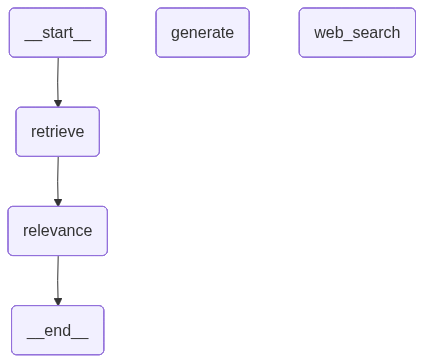

In [17]:
from langgraph.graph import END, START, StateGraph


def route_after_relevance(state: RagState):
    return 'generate' if state.relevant else 'web_search'


rag_wf = StateGraph(RagState)
rag_wf.add_node('retrieve', retrieve_node)
rag_wf.add_node('relevance', relevance_node)
rag_wf.add_node('generate', generate_node)
rag_wf.add_node('web_search', web_search_node)

rag_wf.add_edge(START, 'retrieve')
rag_wf.add_edge('retrieve', 'relevance')
rag_wf.add_conditional_edges('relevance', route_after_relevance)
rag_wf.add_edge('generate', END)
rag_wf.add_edge('web_search', END)

rag_app = rag_wf.compile()
rag_app

### 실행 — 학칙에 있을 법한 질문

In [18]:
# 대학원 학칙만 보고 싶을 때 level='대학원'
out = rag_app.invoke(RagState(question='석사학위과정의 수업연한은 얼마인가요?', level='대학원'))
print('source:', out['source'])
print(out['answer'])


retrieve filter: 대학원 | hits: 4
Relevance: YES → True
source: rag
석사학위과정의 수업연한은 2년(4학기)입니다.


### 실행 — 학칙에 없을 법한 질문 (웹 검색으로 넘어가는지 확인)

In [19]:
out = rag_app.invoke(RagState(question='2026년 최신 HBM4 스펙 요약해줘'))
print('source:', out['source'])
print(out['answer'])

retrieve filter: (없음) | hits: 4
Relevance: NO → False
source: web
2026년의 HBM4(High Bandwidth Memory 4세대) 스펙은 다음과 같습니다:

1. **적층 수**: HBM4는 기존 HBM3의 12단에서 16단으로 적층 수를 늘려 데이터 전송 대역폭을 크게 확대할 것으로 예상됩니다.

2. **데이터 전송 대역폭**: 더 넓은 인터페이스를 통해 데이터 전송 대역폭이 획기적으로 증가할 것으로 보입니다.

3. **전력 효율성**: HBM4는 이전 세대 대비 전력 효율이 약 40% 개선되었습니다.

4. **열 저항 및 방열 특성**: 수직 열 저항 특성은 10%, 방열 특성은 총 30% 개선되었습니다.

5. **적용 분야**: HBM4는 데이터센터 환경에 최적화되어 설계되었습니다.

이 정보는 현재까지의 자료를 바탕으로 한 것이며, 향후 추가적인 세부 사항이 발표될 수 있습니다.


---
## 3. Text2SQL

* "평균이 얼마야?" 같은 **숫자 계산**은 벡터 검색이 아니라 SQL이 맞습니다.
* `table_data.csv`(콘크리트 배합·강도)를 SQLite로 올려 SELECT만 실행합니다.

### CSV → SQLite

In [20]:
import sqlite3

import pandas as pd

df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]

DB_PATH = WORKDIR / 'concrete.db'
conn = sqlite3.connect(DB_PATH)
df.to_sql('concrete', conn, if_exists='replace', index=False)

print(df.shape)
print(df.columns.tolist())
df.head(3)

(1030, 9)
['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Concrete_compressive_strength']


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27


### 스키마 + Few-shot
* LLM은 DB 구조를 모르므로 **스키마**를 함께 줘야 합니다.
* "이런 질문 → 이런 SQL" 예시(Few-shot)를 넣으면 JOIN·집계 실수가 줄어듭니다.

In [21]:
SCHEMA = """
Table: concrete
Columns:
- Cement (float): 시멘트량
- Blast_Furnace_Slag (float)
- Fly_Ash (float)
- Water (float): 물량
- Superplasticizer (float)
- Coarse_Aggregate (float)
- Fine_Aggregate (float)
- Age (int): 양생 일수
- Concrete_compressive_strength (float): 압축강도
"""

FEW_SHOT = """
Q: Age가 28일인 샘플의 평균 압축강도는?
SQL: SELECT AVG(Concrete_compressive_strength) FROM concrete WHERE Age = 28;

Q: Cement가 400 이상인 행은 몇 개인가?
SQL: SELECT COUNT(*) FROM concrete WHERE Cement >= 400;
"""

### SQL 생성
* 응답은 SQL문만 나오게 하고, 실행 전에 **SELECT만 허용**합니다. (안전장치)

In [22]:
def question_to_sql(question: str) -> str:
    prompt = (
        'SQLite SELECT 쿼리만 한 줄로 작성하세요. 설명·코드펜스 금지.\n'
        f'{SCHEMA}\n예시:\n{FEW_SHOT}\n'
        f'질문: {question}\nSQL:'
    )
    sql = llm.invoke(prompt).content.strip().strip('`')
    if sql.lower().startswith('sql'):
        sql = sql[3:].strip()
    return sql


def run_select(sql: str):
    cleaned = sql.strip().rstrip(';')
    if not cleaned.lower().startswith('select'):
        return '오류: SELECT만 허용합니다.', sql
    banned = ('insert', 'update', 'delete', 'drop', 'alter', 'attach')
    low = cleaned.lower()
    if any(b in low for b in banned):
        return '오류: 위험 키워드가 포함되어 실행을 거부합니다.', sql
    try:
        cur = conn.execute(cleaned)
        rows = cur.fetchall()
        cols = [d[0] for d in cur.description] if cur.description else []
        return {'columns': cols, 'rows': rows}, sql
    except Exception as e:
        return f'결과 없음/실행 실패: {e}', sql

### 실행

In [23]:
q = 'Age가 28일인 샘플의 평균 압축강도는 얼마인가?'
sql = question_to_sql(q)
result, sql = run_select(sql)

print('SQL:', sql)
print('결과:', result)

SQL: SELECT AVG(Concrete_compressive_strength) FROM concrete WHERE Age = 28;
결과: {'columns': ['AVG(Concrete_compressive_strength)'], 'rows': [(36.748611764705885,)]}


In [24]:
q = 'Cement가 400 이상인 행은 몇 개인가?'
sql = question_to_sql(q)
result, sql = run_select(sql)

print('SQL:', sql)
print('결과:', result)

SQL: SELECT COUNT(*) FROM concrete WHERE Cement >= 400;
결과: {'columns': ['COUNT(*)'], 'rows': [(138,)]}


### 결과를 자연어로 한 번 더

In [25]:
def sql_answer(question: str) -> str:
    sql = question_to_sql(question)
    result, sql = run_select(sql)
    prompt = (
        f'질문: {question}\n실행 SQL: {sql}\n결과: {result}\n'
        '위 결과를 한두 문장으로 한국어로 설명하세요.'
    )
    return llm.invoke(prompt).content


print(sql_answer('Age가 28일인 샘플의 평균 압축강도는 얼마인가?'))

28일인 샘플의 평균 압축강도는 약 36.75 MPa입니다.


---
## 4. 정리

| 질문 유형 | 도구 |
|-----------|------|
| 규정·절차·정의 | Chroma 검색 (+ Relevance) |
| 평균·건수·집계 | Text2SQL |
| 내부에 없음 | 웹 검색 |

In [26]:
print('=== RAG (대학원 필터) ===')
r = rag_app.invoke(RagState(question='석사 수업연한을 알려줘', level='대학원'))
print(r['source'], '|', r['answer'][:200])

print('\n=== RAG (학부 필터) ===')
r2 = rag_app.invoke(RagState(question='학부 수업연한(졸업이수학기) 관련 규정을 알려줘', level='학부'))
print(r2['source'], '|', r2['answer'][:200])

print('\n=== Text2SQL ===')
print(sql_answer('Water가 200 이상인 샘플의 평균 압축강도는?'))


=== RAG (대학원 필터) ===
retrieve filter: 대학원 | hits: 4
Relevance: YES → True
rag | 석사학위과정의 수업연한은 2년(4학기)입니다. 단, 학위수여 자격 요건을 충족한 학생은 수업연한을 1학기 단축할 수 있습니다.

=== RAG (학부 필터) ===
retrieve filter: 학부 | hits: 4
Relevance: YES → True
rag | 학부 수업연한은 일반적으로 4년(8학기)으로 설정되어 있습니다. 그러나 의예과와 치의예과는 2년(4학기), 약학과는 6년(12학기), 건축학은 5년(10학기)으로 각각 다르게 적용됩니다. 또한, 특정 조건을 충족하는 학생은 수업연한을 2개 학기 이내에서 단축할 수 있습니다.

=== Text2SQL ===
Water가 200 이상인 샘플의 평균 압축강도는 약 33.44 MPa입니다.
